In [59]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from dilithium_py.ml_dsa import ML_DSA_44 # NIST Level 2 (comparable to P-256)

In [40]:
pip install dilithium-py

Note: you may need to restart the kernel to use updated packages.


In [68]:
pip install cryptography

Note: you may need to restart the kernel to use updated packages.


The mathematics of ML-DSA (Module-Lattice-Based Digital Signature Algorithm), standardized in FIPS 204, is built on the Fiat-Shamir with Aborts framework. It relies on the hardness of the Module Learning With Errors (M-LWE) and Module Short Integer Solution (M-SIS) problems.
## Core Mathematical Concepts
* **Polynomial Ring ($\mathbb{R}_q$):** All operations happen within the ring $$\mathbb{R}_q = \mathbb{Z}_q[X]/X^{256} + 1$$

Here, $n = 256$ and $q = 8 380 417$. This means you are adding and multiplying polynomials of degree 255, and every coefficient is kept "in check" by the prime $q$.
* **Number Theoretic Transform (NTT):** This is a specialized version of the Fast Fourier Transform (FFT) used to multiply polynomials in $O(n\ log\ n)$ time instead of $O(n^2)$.

The NTT is an example of a basis vectors change. The basis for the polynomial ring is changed (from the standard basis ${1,x,x^2, ...}$ to a point-evaluation basis). This allows the matrix-vector multiplication to be performed much faster.
  
* **Rejection Sampling:** A critical security mechanism that restarts the signing process if the output might leak information about the private key.



## The Exact Sequence of Steps
1. **Key Generation**
The goal is to create a linear relation that is easy to check but hard to invert.

    1.1 **Generate Matrix $A$:** A $k \times{l}$ matrix of polynomials is expanded from a random seed.
   
    1.2 **Sample Secrets:** Two "short" vectors, $s_1$ and $s_2$ (polynomials with very small coefficients), are chosen.

    $\bullet$ $s_1$ - secret vector (length $l$).

    $\bullet$ $s_2$ - error vector (length $k$).
   
    1.3 **Compute Public Key:** The vector $t = As_1 + s_2$ is calculated. The public key is $(A,t)$.

   $-$ **Purpose:** This creates the **Module-LWE** (Learning with errors) problem. An attacker sees $A$ and $t$, but finding $s_1$ is computationally "hard" because of the added noise $s_2$ and the lattice structure.

   The matrix $A$ (public) and the secret vectors $s_1,s_2$ (private) define a lattice. The public key $t = As_1 + s_2$ is essentially a set of points that are "near" the lattice defined by $A$. Adding the error vector $s_2$ hides the exact lattice points.


    $-$ **Power2Round: Compressing the Public Key ($t$)**

Instead of sending the full values of $t$, ML-DSA "splits" $t$ into two parts:

   $t_1$ **(The High Bits):** This is the compressed version sent in the public key.

   $t_0$ **(The Low Bits):** This is the "remainder" or error created by the compression, which is kept as part of the private key.

ML-DSA uses a power of two, $d = 13$. For each coefficient $r$ in $t$: $$r =r_1 \cdot 2^d + r_0$$

$t_1$ is essentially $r \gg d$ (shifting bits right).

$t_0$ is $r (mod\ a^d)$ (the dropped bits).
Why do this?
By only making $t_1$ public, the public key size is reduced by about 40-50%. During verification, the verifier uses 
 and "reconstructs" the necessary parts of $t$.

   
3. **Signing (The Fiat-Shamir with Aborts Sequence)** To sign a message $M$, the algorithm performs an interactive-style proof turned non-interactive:

    2.1 **Commitment:** Pick a random vector $y$ with small coefficients. Compute $w = Ay$.

    2.2 **Challenge:** Hash the message $M$ and the "high bits" of $w$ to produce a challenge $c$. This ensures the signature is tied to a fresh random value for every message.

    $\bullet$  $c$ is a polynomial with predefined number of coefficients depending on the algorithm variant (60 coefficients in the case of ML-DSA 87) as $\pm1$ and the rest $0$.

    2.3 **Potential Signature:** Compute $z = y + cs_1$. It does not actually contain $w$. Instead, it contains the challenge $c$, which is a HASH of $w_1$ (Low Bits).

    2.4 **The "Abort" Check:** This is the most important step. If $z$ or the "low bits" of the result are too large, they could leak the secret $s_1$. If they exceed a specific bound, the algorithm **restarts** from Step 1.
  
    2.5 **Output:** If it passes, the signature is $(z,c)$.
  
5. **Verification**
The verifier checks if the mathematical identity holds without knowing $s_1$.

    3.1 **Reconstruct Commitment:** The verifier takes the signature $z$ and the public key $t$ and computes $w{\ '} = Az -ct$.

   $-$ _Mathematical Proof:_ $A(y + cs_1) - c(As_1 + s_2) = Ay - cs_2$.

    3.2 **Condition Check:** The verifier checks if:

   $-$ The norm (size) of $z$ is within the allowed bound.

   $-$ The hash of the reconstructed $w'$  matches the challenge $c$ provided in the signature.

   **Purpose:** Because $z = y + cs_1$ and $t = As_1 + s_2$, the term $A(cs_1)$ cancels out, leaving the verifier with a value derived from the original $Ay$. If the hash of this result matches the challenge $c$, the signature is valid.

Example: This is a ring of polynomials:
$$\mathbb{R}_q = \mathbb{Z}_q[X]/X^{256} + 1$$

**Structure of $\mathbb{R}_q$**

$\bullet$ **Elements:** Polynomials of the form $f(x) = a_0 + a_1X + a_2X^2 + \cdot\cdot\cdot + a_{255}X^{255}$.

$\bullet$ **Coefficients:** The coefficients $a_i$ are integers in $\mathbb{Z}_q$, meaning they are taken modulo $q$ (e.g.$q = 8 380 417$, for ML-DSA).

$\bullet$ **Reduction Rule:** Polynomial multiplication is performed modulo $X^{256} + 1$. This implies the relationship $X^{256}\equiv -1 \; (modX^{256} + 1)$.

$\bullet$ **Representation:** As an implementer, this is effectively an array of 256 coefficients, each a uint16 in C. 

**Concrete Example**
Let $q = 3329$ (the modulus used in Kyber) and consider two elements $f(X), g(X) \in \mathbb{R}_q$.
1. **Addition:**

Adding two polynomials is just component-wise addition modulo $q$.

$$f(X) = 2X^2 + 5$$

$$g(X) = 3X^2 + 1$$

$$f(X) + g(X) = (2 + 3)X^2 + (5 + 1) = 5X^2 + 6 \ (mod3329)$$

2. **Multiplication (Reduction Rule):**
Multiplication is polynomial multiplication followed by reducing the degree using $X^{256} = -1$.

Consider a smaller example, $\mathbb{Z}[X]/(X^4 + 1)$, to show the reduction:
Let $f(X) = X^2 and g(X) = X^3.

Since $X^4 \equiv -1$, then $X^5 = X \cdot X^4 \equiv X \cdot (-1) = -X$.

Therefore, $X^2 \cdot X^3 = -X\ (mod X^4 + 1)$. 

In the case of $\mathbb{R}_q = \mathbb{Z}_q[X]/X^{256} + 1$, if a multiplication results in a term $X^{256}$, it becomes $-1$. If it results in $X^{257}$, it becomes $-X$.

In [6]:
# Example of signing
pk, sk = ML_DSA_44.keygen()
#print("pk", pk)
#print("sk", sk)
msg = b"Initial notes for my project."
print(msg)
sig = ML_DSA_44.sign(sk, msg)

print("\nTest Signature Verification:\n")
print("\n* Test with valid signature.\n")
result = ML_DSA_44.verify(pk, msg, sig)
print("Verification result:", result)
print()

print("\n* Test with invalid message.\n")
# Verification will fail with the wrong msg or pk
result = ML_DSA_44.verify(pk, b"", sig)
print("Verification result:", result)
print()
print("\n* Test with invalid public key.\n")
pk_new, sk_new = ML_DSA_44.keygen()
#print("pk_new", pk_new)
#print("sk_new", sk_new)
result = ML_DSA_44.verify(pk_new, msg, sig)
print("Verification negative result:", result)

b'Initial notes for my project.'

Test Signature Verification:


* Test with valid signature.

Verification result: True


* Test with invalid message.

Verification result: False


* Test with invalid public key.

Verification negative result: False


In [50]:
def compare_ecdsa_vs_mldsa(plain_text_message):
    results = {"ECDSA (P-256)": {}, "ML-DSA-44": {}}

    # --- ECDSA ---
    # ECDSA Key Gen & Size
    sk_ec = ec.generate_private_key(ec.SECP256R1())
    pk_ec = sk_ec.public_key()
    results["ECDSA (P-256)"]["pk_size"] = 64
    
    # ECDSA Signing
    start = time.perf_counter()
    sig_ec = sk_ec.sign(plain_text_message, ec.ECDSA(hashes.SHA256()))
    results["ECDSA (P-256)"]["sign_time"] = (time.perf_counter() - start) * 1000
    results["ECDSA (P-256)"]["sig_size"] = len(sig_ec)

    # ECDSA Verification
    start = time.perf_counter()
    pk_ec.verify(sig_ec, plain_text_message, ec.ECDSA(hashes.SHA256()))
    results["ECDSA (P-256)"]["verify_time"] = (time.perf_counter() - start) * 1000

    # --- ML-DSA ---
    # ML-DSA Key Gen & Size
    pk_ml, sk_ml = ML_DSA_44.keygen()
    results["ML-DSA-44"]["pk_size"] = len(pk_ml)
    
    # ML-DSA Signing
    start = time.perf_counter()
    sig_ml = ML_DSA_44.sign(sk_ml, plain_text_message)
    results["ML-DSA-44"]["sign_time"] = (time.perf_counter() - start) * 1000
    results["ML-DSA-44"]["sig_size"] = len(sig_ml)
    # ML-DSA Verification
    start = time.perf_counter()
    ML_DSA_44.verify(pk_ml, message, sig_ml)
    results["ML-DSA-44"]["verify_time"] = (time.perf_counter() - start) * 1000

    return results

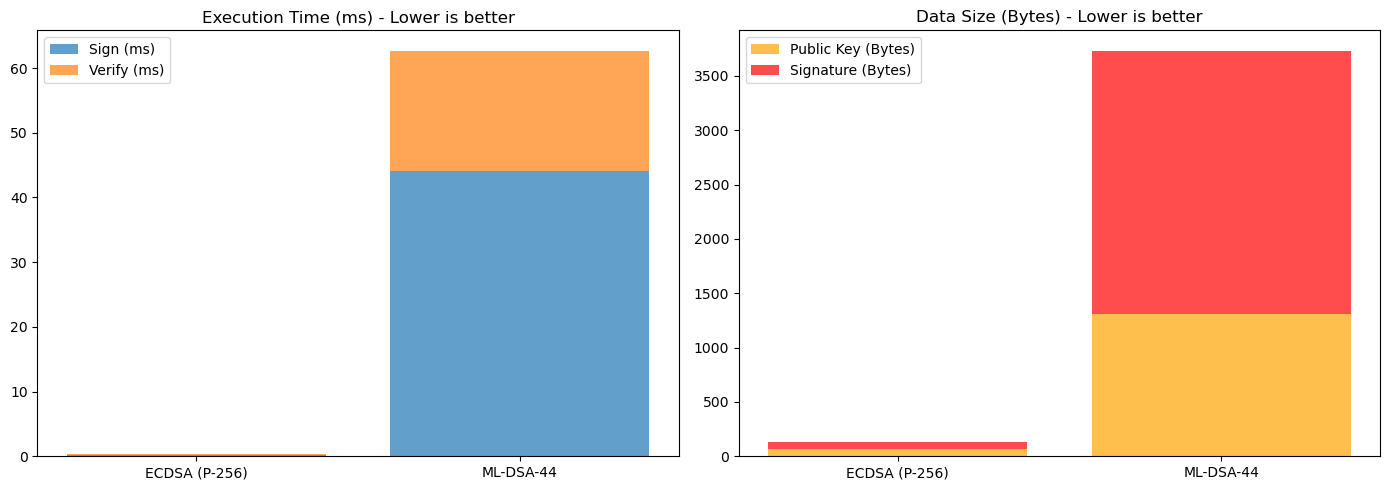

In [53]:
# Run and Plot
message = b"Performance comparison of ECDSA vs ML-DSA!"
data = compare_ecdsa_vs_mldsa(message)
labels = list(data.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot Timing (ms)
sign_times = [data[l]["sign_time"] for l in labels]
verify_times = [data[l]["verify_time"] for l in labels]
axs[0].bar(labels, sign_times, label="Sign (ms)", alpha=0.7)
axs[0].bar(labels, verify_times, bottom=sign_times, label="Verify (ms)", alpha=0.7)
axs[0].set_title("Execution Time (ms) - Lower is better")
axs[0].legend()

# Plot Sizes (Bytes)
pk_sizes = [data[l]["pk_size"] for l in labels]
sig_sizes = [data[l]["sig_size"] for l in labels]
axs[1].bar(labels, pk_sizes, label="Public Key (Bytes)", color='orange', alpha=0.7)
axs[1].bar(labels, sig_sizes, bottom=pk_sizes, label="Signature (Bytes)", color='red', alpha=0.7)
axs[1].set_title("Data Size (Bytes) - Lower is better")
axs[1].legend()

plt.tight_layout()
plt.show()

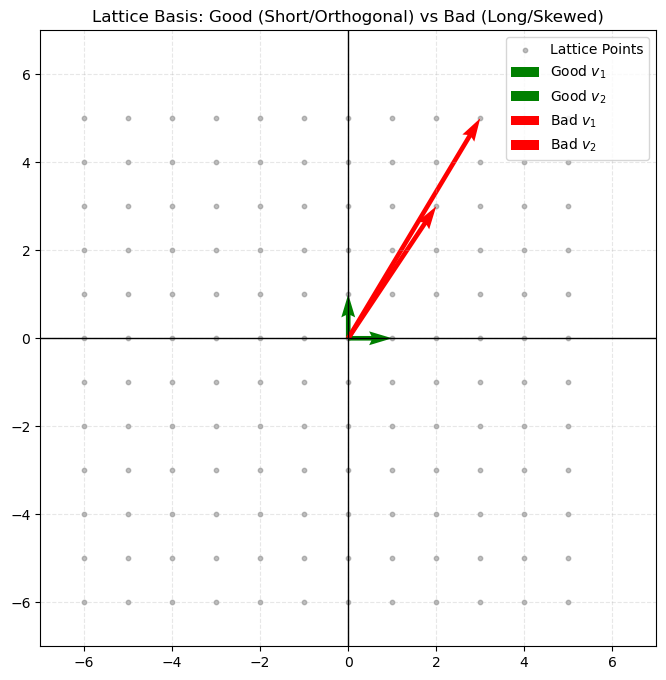

In [55]:
# 1. Define Basis Vectors
# Good basis: short and nearly orthogonal (often private key)
b_good = np.array([[1, 0], [0, 1]]) 
# Bad basis: long and highly skewed (often public key)
# Note: b_bad1 = 2*b_good1 + 3*b_good2, b_bad2 = 3*b_good1 + 5*b_good2
b_bad = np.array([[2, 3], [3, 5]])

# 2. Generate Lattice Points
N = 6
x = np.arange(-N, N)
y = np.arange(-N, N)
X, Y = np.meshgrid(x, y)
# Linear combinations of the good basis to fill the grid
pts = (X.flatten()[:, None] * b_good[0] + Y.flatten()[:, None] * b_good[1])

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pts[:, 0], pts[:, 1], c='gray', s=10, alpha=0.5, label='Lattice Points')

# Helper function to plot vectors using quiver
def plot_vec(basis, color, label_prefix):
    origin = [0, 0]
    ax.quiver(*origin, basis[0, 0], basis[0, 1], color=color, 
              angles='xy', scale_units='xy', scale=1, label=f'{label_prefix} $v_1$')
    ax.quiver(*origin, basis[1, 0], basis[1, 1], color=color, 
              angles='xy', scale_units='xy', scale=1, label=f'{label_prefix} $v_2$')

plot_vec(b_good, 'green', 'Good')
plot_vec(b_bad, 'red', 'Bad')

# Formatting
ax.set_xlim(-7, 7)
ax.set_ylim(-7, 7)
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.set_aspect('equal')
ax.legend()
ax.set_title("Lattice Basis: Good (Short/Orthogonal) vs Bad (Long/Skewed)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

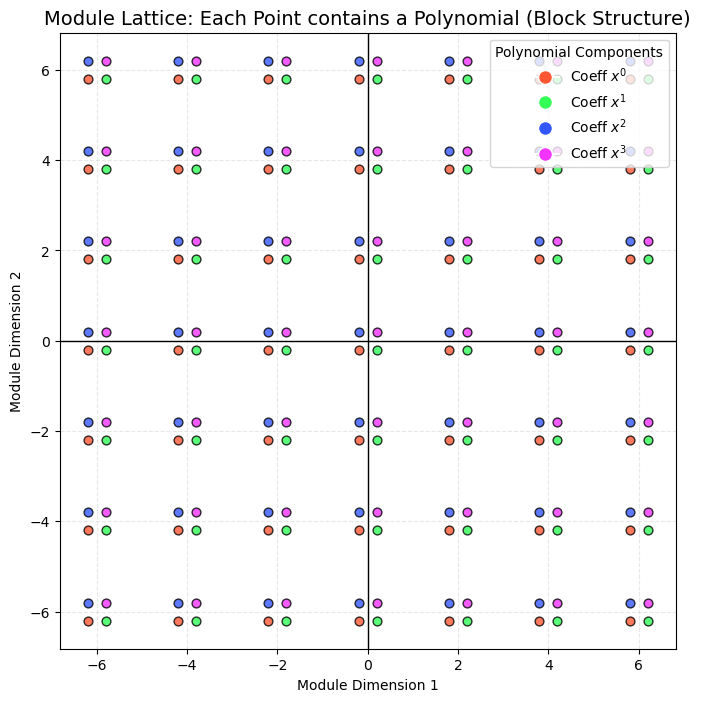

In [56]:
# 1. Define Module Parameters
rank = 2  # The "visible" dimension of the module grid
poly_degree = 4  # Each lattice point is a polynomial (visualized here as 4 sub-points)
grid_size = 3
q = 13  # Modulus example

# 2. Generate Lattice Points
# We create a grid of 'polynomials' (represented by small clusters of colored dots)
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for different polynomial coefficients
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF']

for i in range(-grid_size, grid_size + 1):
    for j in range(-grid_size, grid_size + 1):
        # Base coordinate for this 'Module Point'
        base_x, base_y = i * 2, j * 2
        
        # Plot the 'Internal Structure' of the Module Point
        # In ML-DSA, this represents the polynomial coefficients at this lattice index
        for k in range(poly_degree):
            offset_x = (k % 2 - 0.5) * 0.4
            offset_y = (k // 2 - 0.5) * 0.4
            ax.scatter(base_x + offset_x, base_y + offset_y, 
                       color=colors[k], s=40, edgecolors='black', alpha=0.8)

# 3. Add Legend and Labels
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f'Coeff $x^{m}$',
                          markerfacecolor=colors[m], markersize=10) for m in range(poly_degree)]
ax.legend(handles=legend_elements, title="Polynomial Components", loc='upper right')

# Formatting
ax.set_title("Module Lattice: Each Point contains a Polynomial (Block Structure)", fontsize=14)
ax.set_xlabel("Module Dimension 1")
ax.set_ylabel("Module Dimension 2")
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.show()

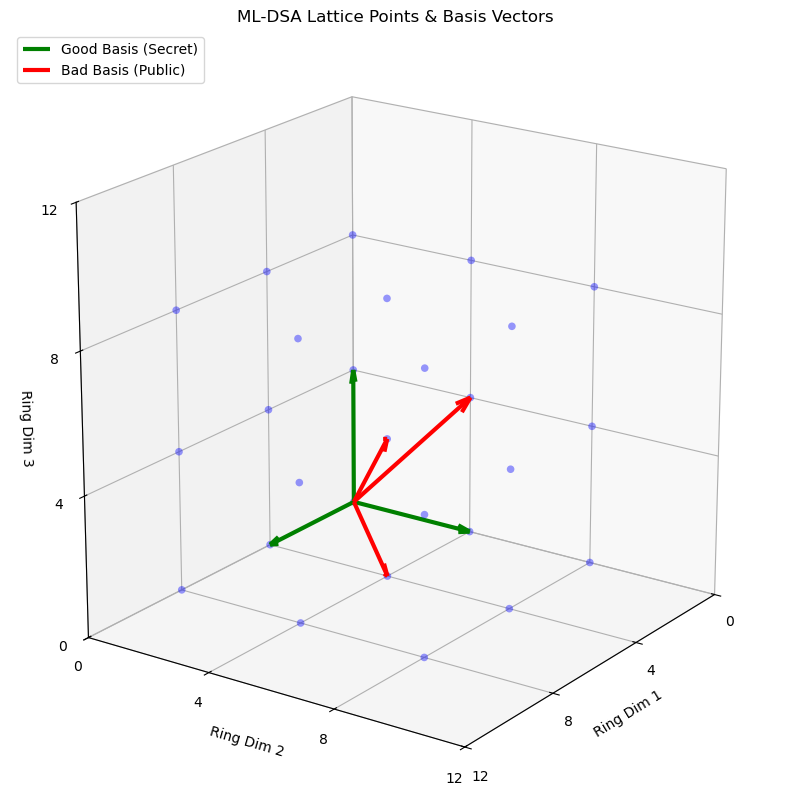

In [69]:
# 1. Setup 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 2. Define Basis Vectors (Module rank 3)
g1, g2, g3 = np.array([4,0,0]), np.array([0,4,0]), np.array([0,0,4])
good_basis = [g1, g2, g3]

# Bad Basis: Linear combinations (Skewed)
b1, b2, b3 = g1+g2, g2+g3, g1+g2+g3 
bad_basis = [b1, b2, b3]

# 3. GENERATE AND PLOT LATTICE POINTS
# We create a 3x3x3 grid based on the Good Basis
for i in range(3):
    for j in range(3):
        for k in range(3):
            # Calculate point: p = i*v1 + j*v2 + k*v3
            p = i*g1 + j*g2 + k*g3
            # Plotting the point on the graphic
            ax.scatter(p[0], p[1], p[2], color='blue', s=30, alpha=0.4, edgecolors='none')

# 4. PLOT VECTORS (Anchored at 0,0,0)
def plot_basis(basis, color, label):
    for i, v in enumerate(basis):
        ax.quiver(0, 0, 0, v[0], v[1], v[2], 
                  color=color, linewidth=3, pivot='tail', arrow_length_ratio=0.1,
                  label=label if i == 0 else "")

plot_basis(good_basis, 'green', 'Good Basis (Secret)')
plot_basis(bad_basis, 'red', 'Bad Basis (Public)')

# 5. FIX AXES AND NUMBERING
limit = 12
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_zlim(0, limit)

# Ensure 0 is exactly at the corner
ax.set_xticks(np.arange(0, limit+1, 4))
ax.set_yticks(np.arange(0, limit+1, 4))
ax.set_zticks(np.arange(0, limit+1, 4))

ax.set_box_aspect([1,1,1]) # Force cubic proportions
ax.view_init(elev=20, azim=35)

ax.set_xlabel('Ring Dim 1')
ax.set_ylabel('Ring Dim 2')
ax.set_zlabel('Ring Dim 3')
ax.set_title("ML-DSA Lattice Points & Basis Vectors")
ax.legend(loc='upper left')

plt.show()